In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [12]:

import pymysql


In [ ]:


conn = pymysql.connect(
    host="localhost",
    user="root",
    password="hiden",
    database="hiden"
)

df = pd.read_sql("SELECT * FROM amazon_orders", conn)
df.head(10)



C:\Users\Admin\AppData\Local\Temp\ipykernel_18452\1423952635.py:8: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql("SELECT * FROM amazon_orders", conn)


,user_id,product_id,category,subcategory,brand,price,discount,final_price,rating,review_count,stock,seller_id,seller_rating,purchase_date,shipping_time_days,location,device,payment_method,is_returned,delivery_status
0,U804996,P51267,Electronics,Men,LG,2738.52,41.62,1598.67,3.4,8,239,S9227,4.0,2025-04-24,4,Delhi,Web,Credit Card,False,Delivered
1,U804996,P51267,Electronics,Men,LG,2738.52,41.62,1598.67,3.4,8,239,S9227,4.0,2025-04-24,4,Delhi,Web,Credit Card,False,Delivered
2,U198246,P67981,Electronics,Headphones,Lenovo,9368.97,5.32,8870.73,3.9,13,119,S9279,4.9,2025-12-12,4,Hyderabad,Tablet,Cash on Delivery,False,In Transit
3,U198246,P67981,Electronics,Headphones,Lenovo,9368.97,5.32,8870.73,3.9,13,119,S9279,4.9,2025-12-12,4,Hyderabad,Tablet,Cash on Delivery,False,In Transit
4,U539898,P79446,Sports,Cycling,Apple,12140.80,48.21,6287.85,3.3,14,403,S4121,4.8,2026-02-09,1,Mumbai,Tablet,UPI,True,Returned
5,U325772,P54118,Sports,Cycling,Apple,12140.80,48.21,6287.85,3.3,14,403,S4121,4.8,2026-02-09,1,Mumbai,Tablet,UPI,False,Delayed
6,U325635,P65390,Home,Kitchen,Lenovo,16120.80,26.11,11911.10,3.6,118,362,S5753,2.6,2025-08-13,6,Mumbai,Web,UPI,False,In Transit
7,U865179,P70217,Home,Decor,Sony,10881.30,48.63,11911.10,3.6,118,362,S5753,2.6,2025-08-13,6,Chennai,Tablet,UPI,False,In Transit
8,U654934,P22176,Sports,Cycling,Boat,7412.68,20.97,5857.89,2.6,36,205,S3904,4.1,2025-02-23,1,Delhi,Web,UPI,False,Delayed
9,U705397,P35203,Home,Decor,Boat,7412.68,20.97,5857.89,2.6,36,205,S3904,4.1,2025-02-23,1,Delhi,Tablet,Cash on Delivery,False,Delivered


In [16]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 393 entries, 0 to 392
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   user_id             393 non-null    str    
 1   product_id          393 non-null    str    
 2   category            393 non-null    str    
 3   subcategory         393 non-null    str    
 4   brand               393 non-null    str    
 5   price               393 non-null    float64
 6   discount            393 non-null    float64
 7   final_price         393 non-null    float64
 8   rating              393 non-null    float64
 9   review_count        393 non-null    str    
 10  stock               393 non-null    str    
 11  seller_id           393 non-null    str    
 12  seller_rating       393 non-null    float64
 13  purchase_date       393 non-null    object 
 14  shipping_time_days  393 non-null    str    
 15  location            393 non-null    str    
 16  device             

In [17]:
df.describe()

,price,discount,final_price,rating,seller_rating
count,393.000000,393.000000,393.000000,393.000000,393.000000
mean,12900.733690,29.787430,9674.714885,3.855725,3.721883
std,16836.652644,14.828711,12867.017008,0.519835,0.739470
min,276.260000,5.320000,169.720000,2.600000,2.500000
25%,2738.520000,17.610000,1755.400000,3.500000,3.100000
50%,6070.930000,28.470000,4141.130000,3.800000,3.700000
75%,14616.100000,39.590000,10440.500000,4.200000,4.400000
max,78801.000000,69.580000,65472.900000,5.000000,5.000000


In [18]:
df.isnull().sum()

user_id               0
product_id            0
category              0
subcategory           0
brand                 0
price                 0
discount              0
final_price           0
rating                0
review_count          0
stock                 0
seller_id             0
seller_rating         0
purchase_date         0
shipping_time_days    0
location              0
device                0
payment_method        0
is_returned           0
delivery_status       0
dtype: int64

In [19]:
df["final_price"].mean()

np.float64(9674.714885496183)

In [20]:
df.groupby("category")["final_price"].sum().sort_values(ascending = False)

category
Electronics    2034256.56
Home            643450.10
Sports          592574.11
Clothing        380945.80
Beauty          150936.38
Name: final_price, dtype: float64

In [21]:
df["is_returned"].value_counts()

is_returned
False    347
True      46
Name: count, dtype: int64

In [22]:
df["is_returned"].value_counts(normalize = True) *100

is_returned
False    88.295165
True     11.704835
Name: proportion, dtype: float64

In [23]:
df.groupby("device")["final_price"].sum()

device
Mobile App    1250625.83
Tablet        1285951.14
Web           1265585.98
Name: final_price, dtype: float64

Top category revenue 

<function matplotlib.pyplot.show(close=None, block=None)>

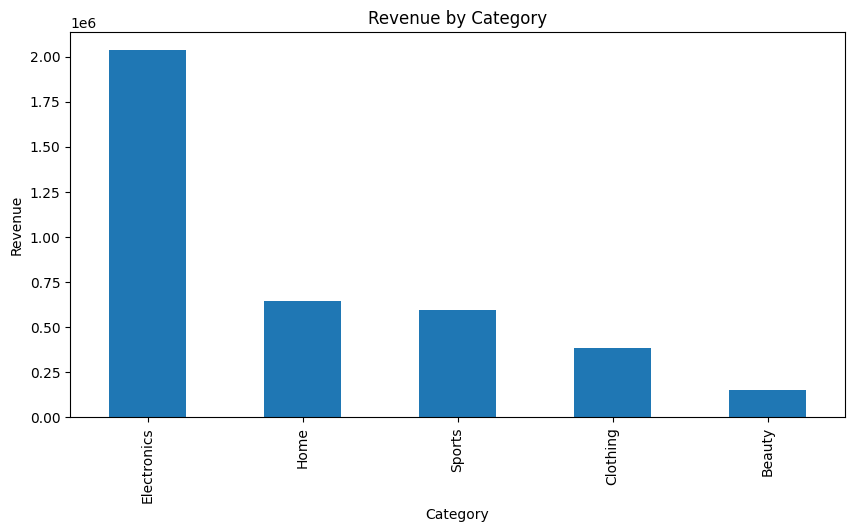

In [29]:
category_revenue = df.groupby('category')["final_price"].sum().sort_values(ascending = False)

plt.figure(figsize= (10,5))
category_revenue.plot(kind = "bar")
plt.title ("Revenue by Category")
plt.xlabel ("Category")
plt.ylabel ("Revenue")

plt.show

        

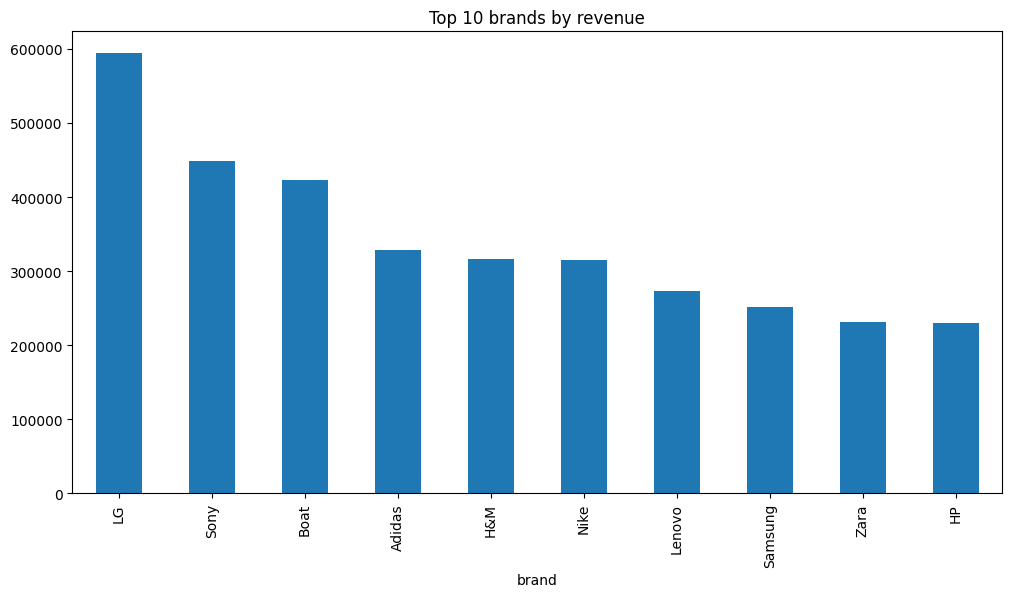

In [31]:
brand_revenue = df.groupby("brand")["final_price"].sum().sort_values(ascending = False).head(10)

plt.figure(figsize = (12,6))
brand_revenue.plot(kind="bar")
plt.title ("Top 10 brands by revenue")
plt.show()

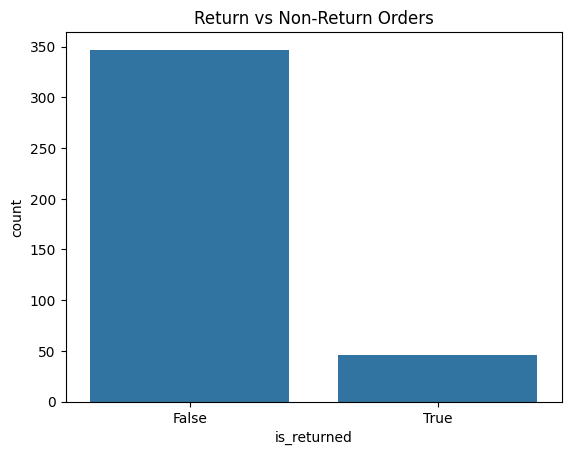

In [33]:
sns.countplot(x="is_returned", data=df)
plt.title ("Return vs Non-Return Orders")
plt.show()

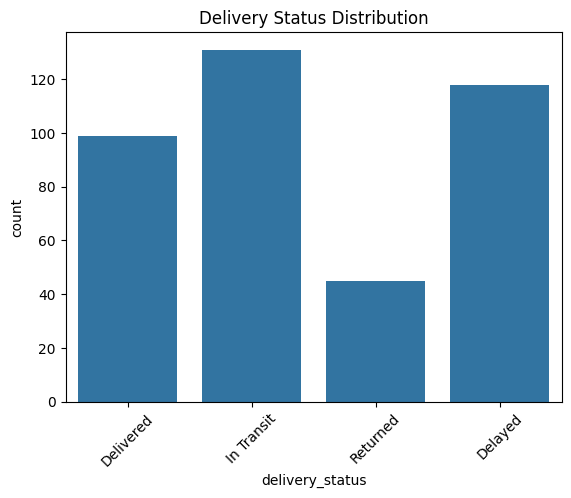

In [34]:
sns.countplot(x="delivery_status", data=df)
plt.title ("Delivery Status Distribution")
plt.xticks(rotation = 45)
plt.show()

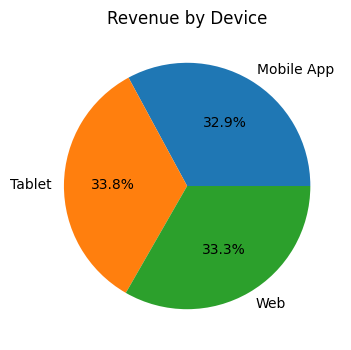

In [35]:
device_revenue = df.groupby("device")["final_price"].sum()

plt.figure(figsize=(6,4))
device_revenue.plot(kind="pie", autopct="%1.1f%%")
plt.title("Revenue by Device")
plt.ylabel("")
plt.show()

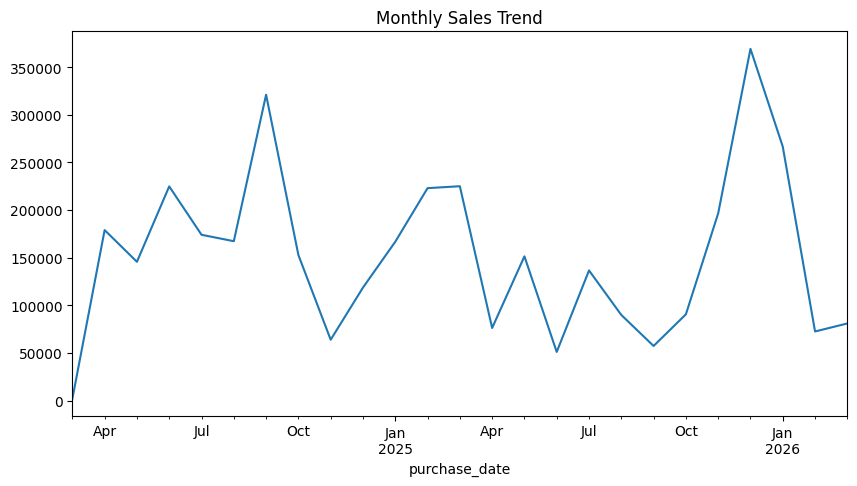

In [36]:
df["purchase_date"] = pd.to_datetime(df["purchase_date"])

monthly_sales = df.groupby(df["purchase_date"].dt.to_period("M"))["final_price"].sum()

plt.figure(figsize=(10,5))
monthly_sales.plot()
plt.title("Monthly Sales Trend")
plt.show()